# Standard Model Effective Potential

In [1]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import matplotlib.lines as mlines
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec

from cosmoTransitions import pathDeformation, transitionFinder
from cosmoTransitions import pathDeformation

from scipy.optimize import minimize, brentq
from scipy.optimize import minimize_scalar

from SM_Potential import Standard_Model

## Define the Model

In [2]:
model = Standard_Model()
v = model.v_os
# Numerical vev from Vtot(T=0)
T_eps = 0  # numerically zero, avoids division by T=0

res = minimize_scalar(
    lambda phi: model.Vtot(np.array([[phi]]), T_eps).item(),
    bounds=(50, 350),
    method='bounded'
)
v_num = res.x
print(f"Numerical vev (Vtot, T=0): {v_num:.3f} GeV")
print(f"CW shift: {abs(v_num - v)/v * 100:.3f}%")

Numerical vev (Vtot, T=0): 246.220 GeV
CW shift: 0.000%


## Coleman weinberg ($T=0$)

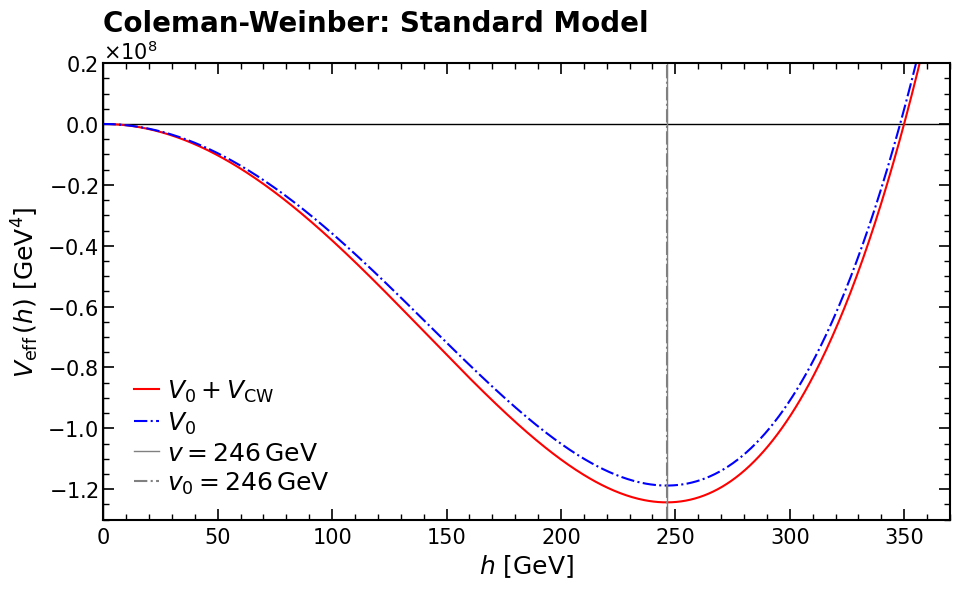

In [11]:
phi_vals = np.linspace(-500, 500, 1500)
X        = phi_vals[:, np.newaxis] 

V_tree   = model.V0(X)
V_tot_0  = model.Vtot(X, 0.0)

fig, ax = plt.subplots(figsize=(9.7, 6))

ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

ax.plot(phi_vals, V_tot_0-model.Vtot(np.array([[0.0]]), 0.0), label=r'$V_0 + V_\mathrm{CW}$', color='r', lw=1.5, ls='-')
ax.plot(phi_vals, V_tree-model.V0(np.array([[0.0]])), label=r'$V_0$', color='b', lw=1.5, ls='-.')

ax.axvline(v_num, label=rf'$v={float(np.squeeze(v_num)):.0f} \, \mathrm{{GeV}}$', color='gray', lw=1.0, ls='-', alpha=1)
ax.axvline(v, label=rf'$v_0={v:.0f} \, \mathrm{{GeV}}$', color='gray', lw=1.5, ls='-.', alpha=1)

ax.set_xlim(0, 370)
ax.set_ylim(-1.3e8, 2e7)

ax.set_xlabel(r'$h$ $\left[\mathrm{GeV}\right]$', fontsize=18)
ax.set_ylabel(r'$V_\mathrm{eff}\,(h)$ $\left[\mathrm{GeV^4}\right]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis='x', which='major', pad=5)

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower left", bbox_to_anchor=(0.01, 0.003),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"Coleman-Weinber: Standard Model", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig("figures\SM_CW.pdf", format="pdf", bbox_inches="tight")

plt.show()

## Thermal Evolution

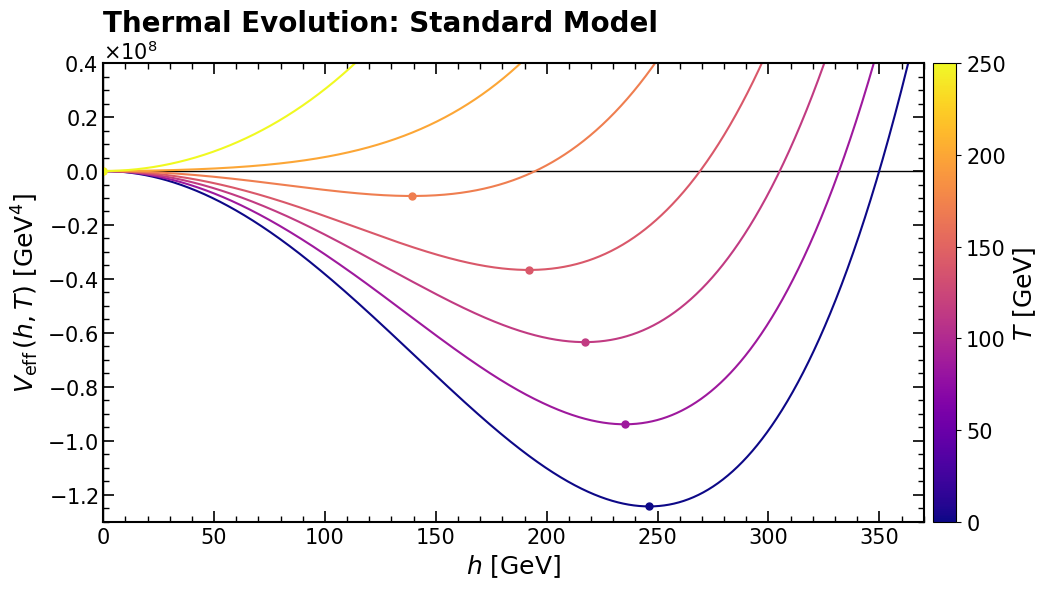

In [9]:
T_vals   = np.array([0, 85, 115, 140, 170, 200, 250])
phi_vals = np.linspace(-1,400,2000)
X        = phi_vals[:, np.newaxis]

# Colormap
cmap  = plt.cm.plasma
norm  = Normalize(vmin=0, vmax=T_vals.max())
sm    = ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(figsize=(9.7, 6))

ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

for T in T_vals:
    V = model.Vtot(X, T)
    V_norm = V - model.Vtot(np.array([[0.0]]), T)
    color = cmap(norm(T))
    label = r'$T = 0$' if T < 1 else rf'$T = {T:.0f}$ GeV'
    ax.plot(phi_vals, V_norm, color=color, lw=1.5, label=label)

    # Mark the minimum of the broken phase
    mask = phi_vals > 0          # Impose Positive vev
    idx  = np.argmin(V[mask])
    phi_min = phi_vals[mask][idx]
    V_min   = V[mask][idx]
    ax.plot(phi_min, V_min-model.Vtot(np.array([[0.0]]), T), 'o', color=color, ms=5)

ax.set_xlim(0, 370)
ax.set_ylim(-1.3e8, 4e7)

ax.set_xlabel(r'$h$ $\left[\mathrm{GeV}\right]$', fontsize=18)
ax.set_ylabel(r'$V_\mathrm{eff}\,(h, T)$ $\left[\mathrm{GeV^4}\right]$', fontsize=18)

ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# Configure ticks
ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$T\ [\mathrm{GeV}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)


#annotation = (rf"$T_c   = 111.01 \, \mathrm{{GeV}}$"  "\n"rf"$\xi_c = 1.58$" "\n"rf"$T_n = 103.57 \, \mathrm{{GeV}}$")
#ax.text(0.05, 0.25, annotation,transform=ax.transAxes,fontsize=18,verticalalignment='top',horizontalalignment='left')

plt.title(r"Thermal Evolution: Standard Model", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig("figures\SM_Thermal.pdf", format="pdf", bbox_inches="tight")

plt.show()